## Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
from google.cloud import bigquery
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()

PROJECT_ROOT = Path.cwd().parents[0]  # jupyter/ -> bgg/
DATA_DIR = PROJECT_ROOT / "data" / "after"
CACHE_DIR = DATA_DIR / "nb_cache_04"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ID = os.environ["GCP_PROJECT_ID"]
client = bigquery.Client(project=PROJECT_ID)

print(f"ROOT:\t{PROJECT_ROOT}")
print(f"CACHE:\t{CACHE_DIR}")
print(f"GCP:\tConnected to Project: {client.project}")

ROOT:	/Users/mungughyeon/Documents/internship/Likelion/bgg
CACHE:	/Users/mungughyeon/Documents/internship/Likelion/bgg/data/after/nb_cache_04
GCP:	Connected to Project: bgg-user-analytics


In [3]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import setup_font


def load_cache(name: str, sql: str, refresh: bool = False) -> pd.DataFrame:
    """캐시 CSV가 있으면 그걸 읽고, 없거나 refresh=True면 BigQuery에 쿼리해 캐시"""
    cache_path = CACHE_DIR / f"{name}.csv"
    if not cache_path.exists() or refresh:
        client.query(sql).to_dataframe().to_csv(cache_path, index=False)
    return pd.read_csv(cache_path)

Hangul OK in your MAC!


In [4]:
SEGMENT_COLORS = {
    "0.미플레이": "#9CA3AF",
    "1.몰입형": "#2E7D6B",
    "2.수집가형": "#E0A72E",
    "3.집중형": "#3B82C4",
    "4.저관여형": "#D9776B",
}
SEGMENT_ORDER = list(SEGMENT_COLORS.keys())
PLAYER_ORDER = SEGMENT_ORDER[1:]

In [5]:
funnel_user = load_cache("funnel_user", '''
    SELECT * FROM `bgg_mart.funnel_user`
''')

funnel_item = load_cache("funnel_item", '''
    SELECT * FROM `bgg_mart.funnel_item`
''')

user_info = load_cache("user_info_04", '''
    SELECT user_id, lastlogin FROM `bgg_staging.stg_user_info`
''')

plays_sample = load_cache("plays_sample_04", '''
    SELECT user_id, yearregistered FROM `bgg_staging.stg_plays_sample`
''')

# 개별 플레이 로그 — 01에서 확립한 정상 구간(2001~2026-09-07) 필터를 그대로 적용
user_play = load_cache("user_play_04", '''
    SELECT user_id, objectid, play_date
    FROM `bgg_staging.stg_user_play`
    WHERE play_date IS NOT NULL AND play_date BETWEEN "2001-01-01" AND "2026-09-07"
''')

print(f"funnel_user {funnel_user.shape}, plays_sample {plays_sample.shape}, user_play {user_play.shape}")

funnel_user (3000, 8), plays_sample (1065, 2), user_play (1266896, 3)


<a id="sec-bg"></a>
## 배경

- [EDA](01.EDA.ipynb): 활동량이 소수에 극단적으로 쏠려 있음을 확인(지니계수 0.78~0.80)
- [Funnel 분석](02.Funnel_Retention.ipynb)은 보유 게임 수 같은 단일 지표로 유저를 나누면 착시가 생긴다는 걸 확인(`play_game_ratio`와 역상관). 
- [Segment 분석](03.Segment_Wishlist.ipynb)은 보유 게임 수×활용도 2×2 세그먼트를 만들고 비지도 군집화로 보조 검증까지 마쳤다.

> 세 분석 모두 **한 시점에 모은 데이터**로 유저를 봤다.  
> 아직 확인 안 된 축은 시간뿐이다. 세 개의 미해결 질문이 남아 있다.

- [EDA](01.EDA.ipynb) 8-1: "반복 플레이"까지만 말하고 "지속 참여"라 부르지 않는다고 유보했다.
- [Segment 분석](03.Segment_Wishlist.ipynb) 결론: 세그먼트가 시간이 지나도 유지되는지, 그리고 군집화가 찾아낸 로그인 경과일 축이 실제로 무엇을 뜻하는지 검증이 필요하다고 남김
- [EDA](01.EDA.ipynb) 1-4: 가입연도 흐름에 정체와 2021년 급감 구간이 있다는 걸 확인했지만, 이게 실제 참여로 이어지는지는 안 봤다.

> 아래 세 가설을 순서대로 검증한다.

- **H1**: 반복 플레이한 유저는 안 한 유저보다 실제 활동 기간이 더 길 것이다
- **H2**: 보유 게임 수·활용도로 나눈 세그먼트 간 활동 지속성 차이는 시간이 지나도 유지될 것이다
- **H3**: 최근에 가입한 유저일수록 실제로 게임을 플레이하는 비율이 더 낮을 것이다

**다루지 않는 것**: 
    - `sql/marts/cohort.sql`의 `cohort_retention_long`(코호트연도×경과년수 리텐션)은 그레인상 세그먼트와 못 엮이고, "경과년수"가 가입 후 경과가 아니라 캘린더 연도 활동 여부를 재는 구조라 플랫폼 성숙도와 뒤섞인다. 
    - H3는 이 마트 대신 원본 로그를 직접 코호트로 나눠 다른 방식으로 본다. 
    - `sql/marts/trend.sql`(게임 카탈로그 트렌드)은 유저 행동이 아닌 별개 축이라 다루지 않는다. 
    - 두 마트 모두 이미 준비돼 있다는 사실만 결론에서 짚는다.

**인구 경계**: 
    - 시간축 분석의 모집단은 `stg_plays_sample`(1,065명) 중 실제 플레이 로그가 있는 유저다. 
    - `funnel_user`(3,000명)나 `is_owner`(2,944명) 전체가 아니다.

<a id="sec-1"></a>
## 1. 반복해서 플레이한 유저는 실제로도 오래 활동하는가

- [EDA](01.EDA.ipynb) 8-1은 "반복 플레이"(소유 게임 중 2회 이상 플레이한 게임 1개 이상)까지만 말하고 "지속 참여"라 부르지 않겠다고 유보했다. 
- 시점 정보가 없는, 한 시점에 확인한 지표라 시간적 의미를 확정할 수 없었기 때문이다. 
- 이제 실제 플레이 로그로 그 유보를 검증한다.

,n,활동연수_중앙값,최근성_중앙값,총플레이_중앙값
has_repeat_play_record,,,,
False,82,1.0,7.0,2.0
True,647,8.0,0.0,947.0


활동 연수 Mann-Whitney: p=7.81e-33, rank-biserial r=-0.81 (반복플레이 있음 n=647, 없음 n=82)


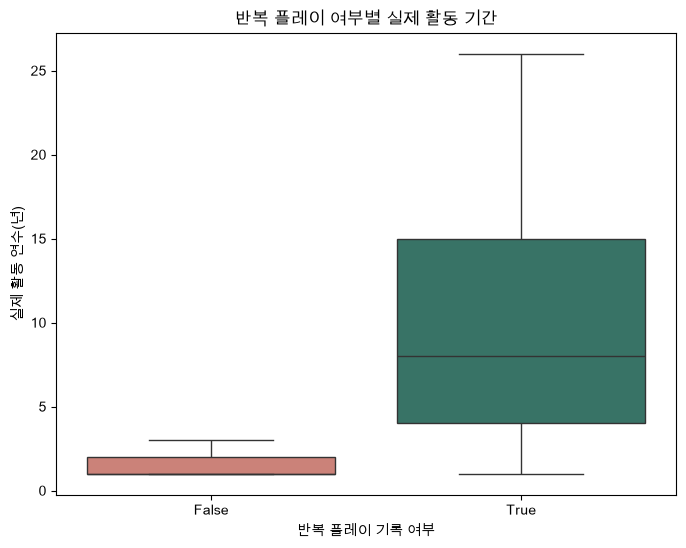

In [6]:
up = user_play.copy()
up["play_year"] = pd.to_datetime(up["play_date"]).dt.year
byu = up.groupby("user_id").agg(
    first_year=("play_year", "min"),
    last_year=("play_year", "max"),
    n_years_active=("play_year", "nunique"),
    n_plays=("play_date", "size"),
)
byu["recency_years"] = 2026 - byu["last_year"]

h1 = byu.merge(funnel_user.set_index("user_id")[["has_repeat_play_record"]], left_index=True, right_index=True, how="left")
h1 = h1.dropna(subset=["has_repeat_play_record"])

summary = h1.groupby("has_repeat_play_record").agg(
    n=("n_plays", "size"),
    활동연수_중앙값=("n_years_active", "median"),
    최근성_중앙값=("recency_years", "median"),
    총플레이_중앙값=("n_plays", "median"),
)
display(summary)

g1 = h1[h1.has_repeat_play_record]["n_years_active"]
g0 = h1[~h1.has_repeat_play_record]["n_years_active"]
u_stat, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
r = 1 - (2 * u_stat) / (len(g1) * len(g0))
print(f"활동 연수 Mann-Whitney: p={p:.2e}, rank-biserial r={r:.2f} (반복플레이 있음 n={len(g1)}, 없음 n={len(g0)})")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=h1, x="has_repeat_play_record", y="n_years_active", showfliers=False,
            palette=["#D9776B", "#2E7D6B"], ax=ax)
ax.set_title("반복 플레이 여부별 실제 활동 기간")
ax.set_xlabel("반복 플레이 기록 여부")
ax.set_ylabel("실제 활동 연수(년)")
plt.show()

**결과**

- 반복 플레이한 유저(647명)는 실제 활동 연수 중앙값이 8년이고 2026년까지 활동이 이어지는 것으로 확인
- 없는 유저(82명)는 활동 연수 중앙값 1년, 마지막 활동이 7년 전으로 확인
    - 효과크기가 매우 큼(r≈-0.81)
- 이는 반복 플레이라는, 한 시점에 확인한 지표가 실제 장기 지속성과 강하게 연결된다는 것을 시사(상관 확인이지 인과 확인은 아님)
- 이 결과 위에서, 세그먼트도 실제 시간축에서 유지되는지 다음 절에서 확인한다


<a id="sec-2"></a>
## 2. 세그먼트는 시간이 지나도 유지되는가

- [Segment 분석](03.Segment_Wishlist.ipynb)의 보유 게임 수×활용도 2×2 세그먼트는 카이제곱·비지도 군집화로 검증됐지만, 
- 전부 한 시점의 데이터로 한 검증이다. 
- 세그먼트별로 실제 플레이 로그의 활동 궤적을 비교해, 이 구분이 시간이 지나도 유지되는지 확인한다.

,인원,활동span_년,활동연수_중앙값,최근성_중앙값,총플레이_중앙값
segment5,,,,,
0.미플레이,28,0.0,1.0,8.5,1.0
1.몰입형,152,13.0,13.0,0.0,3287.5
2.수집가형,188,10.0,8.0,0.0,500.0
3.집중형,194,8.0,8.0,0.0,1158.0
4.저관여형,162,1.0,2.0,4.0,25.0


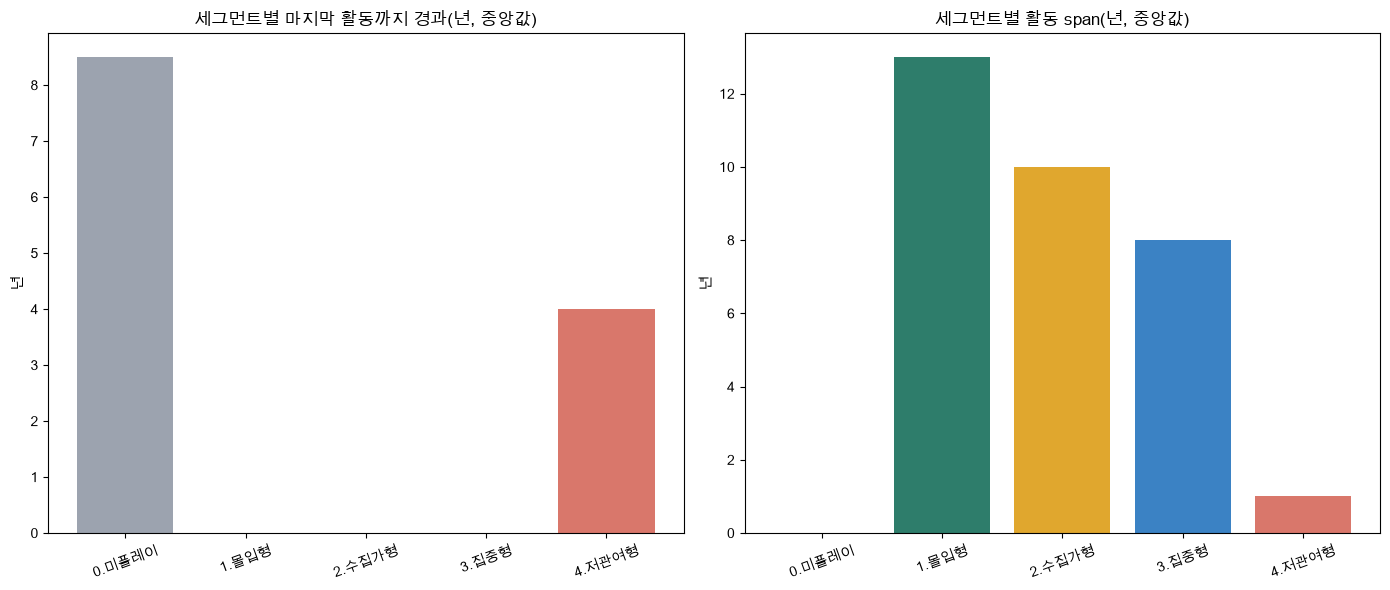

In [7]:
owners = funnel_user[funnel_user["is_owner"]].copy()
players = owners[owners["has_play_record"]].copy()
players = players.merge(user_info, on="user_id", how="left")
players["rating_ratio"] = players["n_rated"] / players["n_owned"]
play_ratio = funnel_item.groupby("user_id")["has_play_record"].mean().rename("play_game_ratio")
players = players.merge(play_ratio, on="user_id", how="left")

med_owned = players["n_owned"].median()
med_ratio = players["play_game_ratio"].median()
players["segment5"] = np.select(
    [
        (players["n_owned"] >= med_owned) & (players["play_game_ratio"] >= med_ratio),
        (players["n_owned"] >= med_owned) & (players["play_game_ratio"] < med_ratio),
        (players["n_owned"] < med_owned) & (players["play_game_ratio"] >= med_ratio),
    ],
    ["1.몰입형", "2.수집가형", "3.집중형"],
    default="4.저관여형",
)
owners["segment5"] = "0.미플레이"
for seg in PLAYER_ORDER:
    owners.loc[owners.user_id.isin(players[players.segment5 == seg].user_id), "segment5"] = seg

traj = byu.merge(owners.set_index("user_id")["segment5"], left_index=True, right_index=True, how="left")
traj = traj.dropna(subset=["segment5"])
traj["span_years"] = traj["last_year"] - traj["first_year"]

seg_summary = traj.groupby("segment5").agg(
    인원=("n_plays", "size"),
    활동span_년=("span_years", "median"),
    활동연수_중앙값=("n_years_active", "median"),
    최근성_중앙값=("recency_years", "median"),
    총플레이_중앙값=("n_plays", "median"),
).reindex(SEGMENT_ORDER)
display(seg_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rec = traj.groupby("segment5")["recency_years"].median().reindex(SEGMENT_ORDER)
axes[0].bar(rec.index, rec.values, color=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
axes[0].set_title("세그먼트별 마지막 활동까지 경과(년, 중앙값)")
axes[0].set_ylabel("년")
axes[0].tick_params(axis="x", rotation=20)

span = traj.groupby("segment5")["span_years"].median().reindex(SEGMENT_ORDER)
axes[1].bar(span.index, span.values, color=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
axes[1].set_title("세그먼트별 활동 span(년, 중앙값)")
axes[1].set_ylabel("년")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**결과**

- 몰입형·수집가형·집중형은 2026년까지 활동이 이어지고(최근성 중앙값 0년), 활동 span도 8~13년으로 긴 것으로 확인
- 저관여형만 마지막 활동이 4~5년 전이고 활동 span도 1년뿐인 것으로 확인
- 세그먼트 구분 자체는 시간축에서도 유효하다는 것을 시사
    - 다만 반전이 하나 확인됨: [Segment 분석](03.Segment_Wishlist.ipynb)이 "착시 위험군"으로 지목한 수집가형은 시간축으로 보면 몰입형·집중형과 마찬가지로 여전히 활동 중
    - 실제로 재참여가 끊긴 건 그때 "재활성화 우선순위 낮음"으로 분류했던 저관여형으로 확인
    - 세그먼트 구분은 유효하지만, 어느 세그먼트가 "위험"인지는 한 시점 데이터로 봤을 때의 판단과 다르게 나온다는 것을 시사


### 2-1. K-means 활동축은 실제 궤적과 일치하는가

- [Segment 분석](03.Segment_Wishlist.ipynb)의 비지도 군집화는 세그먼트 정의에 안 쓴 축(로그인 경과일)으로 갈리는 네 번째 군집을 탐색적으로 찾아냈다. 
- 그 군집이 실제 플레이 로그의 최근성과 일치하는지 같은 파라미터로 재현해 확인한다.

In [8]:
players["log_owned"] = np.log1p(players["n_owned"])
players["days_since_login"] = (pd.Timestamp("2026-09-07") - pd.to_datetime(players["lastlogin"], errors="coerce")).dt.days
players["log_dsl"] = np.log1p(players["days_since_login"].fillna(players["days_since_login"].median()))

feat_cols = ["log_owned", "play_game_ratio", "rating_ratio", "log_dsl"]
X = players[feat_cols].fillna(players[feat_cols].median())
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
players["kmeans_cluster"] = kmeans.labels_

players = players.merge(byu["recency_years"], left_on="user_id", right_index=True, how="left")

cluster_summary = players.groupby("kmeans_cluster").agg(
    인원=("user_id", "size"),
    로그인경과일_중앙값=("days_since_login", "median"),
    실로그보유율=("recency_years", lambda s: s.notna().mean()),
    실제최근성_중앙값=("recency_years", "median"),
)
display(cluster_summary.round(2))

sub = players.dropna(subset=["recency_years"])
rho, p = stats.spearmanr(sub["days_since_login"], sub["recency_years"])
print(f"스피어만(로그인 경과일, 실제 플레이로그 최근성): rho={rho:.3f}, p={p:.2e}, n={len(sub)}")

,인원,로그인경과일_중앙값,실로그보유율,실제최근성_중앙값
kmeans_cluster,,,,
0,678,6.0,0.34,0.0
1,643,6.0,0.35,0.0
2,295,596.0,0.36,6.0
3,372,6.0,0.37,3.0


스피어만(로그인 경과일, 실제 플레이로그 최근성): rho=0.485, p=2.16e-42, n=696


**결과**

- 로그인 경과일 중앙값이 유독 높은 군집(약 600일)의 실제 플레이 로그 최근성 중앙값도 6년으로 확인
    - 다른 세 군집(0~3년)보다 뚜렷이 높음
    - 로그인 경과일과 실제 최근성의 스피어만 상관은 0.49(p<0.001)로 중간 수준의 관계로 확인
- 탐색적 발견이 실제 시간 정보를 담고 있었다는 두 번째 독립 근거로 확인
- 로그인 경과일은 완벽하지는 않지만 실제 참여 지속성의 쓸 만한 대리 지표로 관찰된다


<a id="sec-3"></a>
## 3. 최근에 가입한 유저일수록 실제로 게임을 해서 기록을 덜 남기는가

- [EDA](01.EDA.ipynb) 1-4는 가입연도 흐름에 정체와 2021년 급감 구간이 있다는 걸 확인했지만, 
- 이게 "가입만 줄어든 것"인지 "가입은 했는데 실제 참여로 이어지지 않는 비율이 늘어난 것"인지는 보지 않았다. 
- 프로젝트 목표(신규 유입 정체 대응)와 가장 직접 연결되는 질문이라 여기서 확인한다.

,인원,실로그_보유율
cohort_bin,,
~2005,186,0.854839
2006-10,215,0.744186
2011-15,215,0.693023
2016-20,215,0.702326
2021+,234,0.470085



참고: 로그 있는 유저 중 최근 2년 내 활동 비율(관찰 기간이 짧은 최근 코호트에 유리한 편향 있음)
cohort_bin
~2005      0.597484
2006-10    0.531250
2011-15    0.671141
2016-20    0.748344
2021+      0.909091
Name: recency_years, dtype: float64


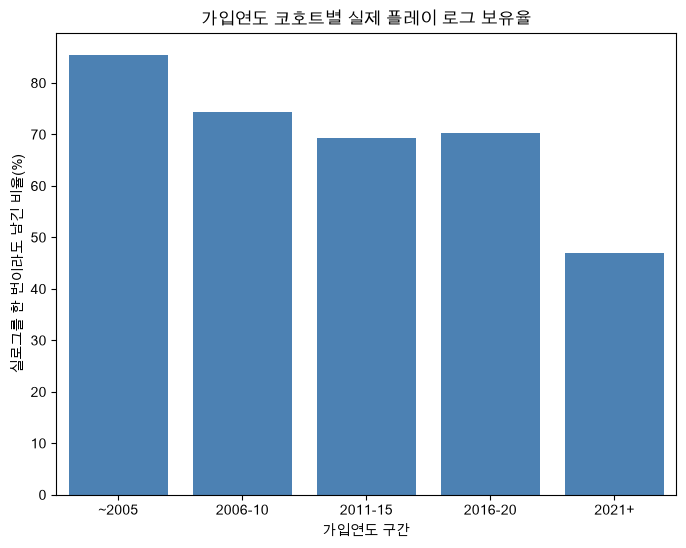

In [9]:
ps = plays_sample.copy()
ps["cohort_bin"] = pd.cut(ps["yearregistered"], [1998, 2005, 2010, 2015, 2020, 2027],
                           labels=["~2005", "2006-10", "2011-15", "2016-20", "2021+"])
ps["has_log"] = ps["user_id"].isin(byu.index)

cohort_summary = ps.groupby("cohort_bin", observed=True).agg(
    인원=("user_id", "size"),
    실로그_보유율=("has_log", "mean"),
)
display(cohort_summary)

# 참고 지표: 로그가 있는 사람 중 최근 2년 내 활동 비율(관찰 기간 편향 있음, 참고만)
ps_log = ps[ps.has_log].merge(byu["recency_years"], left_on="user_id", right_index=True, how="left")
recent_rate = ps_log.groupby("cohort_bin", observed=True)["recency_years"].apply(lambda s: (s <= 2).mean())
print("\n참고: 로그 있는 유저 중 최근 2년 내 활동 비율(관찰 기간이 짧은 최근 코호트에 유리한 편향 있음)")
print(recent_rate)

plt.figure(figsize=(8, 6))
sns.barplot(x=cohort_summary.index, y=cohort_summary["실로그_보유율"] * 100, color="#3B82C4")
plt.title("가입연도 코호트별 실제 플레이 로그 보유율")
plt.xlabel("가입연도 구간")
plt.ylabel("실로그를 한 번이라도 남긴 비율(%)")
plt.show()

**결과**

- 실제 플레이 로그를 한 번이라도 남긴 비율이 ~2005년 가입 코호트 85.5%에서 2021년 이후 가입 코호트 47.0%까지 떨어지는 것으로 확인
- "최근 2년 내 활동 비율"은 최근 코호트일수록 오히려 높게 나오는 것으로 확인
    - 이는 관찰 기간 자체가 짧아 유리해지는 편향이라 그대로 해석하지 않는다
- 최근 가입 코호트일수록 "가입"에서 "실제로 게임을 해서 기록을 남기는 것"까지 이어지는 비율 자체가 낮아진다는 것을 시사
    - [Funnel 분석](02.Funnel_Retention.ipynb)이 확인한 보유→플레이 감소(-32.5%p)가 고정된 상수가 아니라 최근으로 갈수록 더 벌어지고 있을 가능성을 시사
    - 코호트당 표본이 150~230명 수준이라 방향성으로 읽는다


<a id="sec-4"></a>
## 4. 결론

- H1(반복 플레이와 실제 지속 활동의 관계): 채택
    - 같은 게임을 두 번 이상 한 기록이 있으면, 실제로도 활동을 오래 이어가는 것으로 확인
- H2(유형 구분이 시간이 지나도 유지되는가): 부분 채택
    - 유형 구분 자체는 시간이 지나도 유효하지만, 어느 쪽이 위험한지는 다시 잡아야 함
    - 수집가형이 아니라 저관여형이 실제로 몇 년째 돌아오지 않은 집단으로 확인
    - 군집화가 찾아낸 시간 축도 실제 활동 최근성과 어느 정도 같은 방향(상관 0.49)이라 이 결론을 뒷받침
- H3(최근 가입자의 기록 남김 비율): 채택(방향만)
    - 최근에 가입한 유저일수록 실제로 게임을 해서 기록을 남기는 비율이 낮음

H2에서는 예상이 뒤집혔다. [Segment 분석](03.Segment_Wishlist.ipynb)까지는 "많이 갖고 안 쓰는" 수집가형을 위험군으로 봤는데, 실제 활동 기록을 열어보니 수집가형은 지금도 꾸준히 활동 중이었다. 정작 몇 년째 돌아오지 않은 쪽은 적게 갖고 그마저도 안 쓰던 저관여형이었다. 한 시점의 데이터만 봤다면 엉뚱한 집단에 재활성화 캠페인을 돌렸을 것이다.


<a id="sec-5"></a>
## 5. 프로젝트 종합

- 목표(유저 행동과 게임 데이터를 분석해 신규 유저 유입 정체 문제에 대응할 마케팅/그로스 전략을 도출하는 것)로 돌아가 정리한다.

### 5-1. 핵심 인사이트

- 유저를 가장 많이 잃는 순간은 게임을 산 뒤 처음 플레이하기까지다([Funnel 분석](02.Funnel_Retention.ipynb))
    - 게다가 이 문턱은 고정돼 있지 않고, 최근에 가입한 사람일수록 넘는 비율이 더 낮아지고 있다(H3)
- 같은 게임을 두 번 이상 반복 플레이했다는 사실 하나가, 그 사람이 앞으로 몇 년을 더 활동할지와 강하게 연결돼 있다(H1)
    - 한 시점 데이터만 보고 내린 판단이 근거 없는 추측은 아니었다는 뜻이다
- 많이 가진 유저가 잘 쓰는 유저는 아니다
    - 비율 지표, 군집화, 실제 활동 기록이라는 서로 다른 세 방향에서 같은 결론이 나왔다(H2)
- 진짜 위험한 쪽은 많이 갖고 안 쓰는 사람이 아니라, 적게 갖고도 몇 년째 돌아오지 않는 사람이다(H2)
- 평가만 하고 플레이는 하지 않는 층이 실제로 존재하고, 위시리스트는 곧 살 것의 예고가 아니라 관심 표시에 가깝다([Segment 분석](03.Segment_Wishlist.ipynb))

### 5-2. 그로스 전략 제안

아래 액션은 위 인사이트에서 도출한 제안이다. 다만 데이터가 인과를 증명한 것이 아니라 관찰된 패턴에서 나온 가설이므로, 각 행에 실행 후 확인할 검증 방법을 함께 적었다.

| 타깃 | 근거 | 제안 액션 | 검증 방법(제안) |
|---|---|---|---|
| 최근 가입자(2021년 이후) | H3 | 가입 후 3일 안에 유저가 실제로 한 행동에 맞춰 자동으로 안내 메일 발송: 가입 즉시 "첫 게임 등록하는 법" 안내 → 24시간 지나도 안 하면 리마인드 → 3일째까지 기록이 없으면 입문용 게임 추천. 정해진 시간마다 일괄 발송하는 것보다 유저 행동에 반응해 보내는 메일의 전환율이 2~3배 높고, 가입 후 3일 안에 아무 활동이 없으면 이탈 확률이 90% 뛴다는 SaaS 업계 사례 참고 | 가입 후 3일 내 첫 플레이 기록률(코호트별 비교) |
| 게임을 산 직후의 모든 유저 | [Funnel 분석](02.Funnel_Retention.ipynb) 최대 손실 구간(-32.5%p) | 게임 등록 즉시 "첫 플레이를 기록하면 배지를 준다"는 작은 목표 제공, 7일째까지 기록이 없는 유저에게 "플레이 기록하는 법" 안내 메일 발송. 듀오링고가 배지·연속 학습일 같은 작은 성취 요소로 완료율을 30%가량 끌어올린 사례 참고 | A/B 테스트로 배지 노출군 vs 비노출군의 첫 플레이 전환율 비교 |
| 저관여형(몇 년째 안 돌아옴) | H2 | 메일 한 통이 아니라 3~5회에 걸쳐 순서대로 발송: 1차는 가볍게(마지막 활동일·보유 게임 언급) → 2차는 취향에 맞는 신작 소개 → 3차는 확실한 혜택(제휴 게임샵 할인쿠폰)으로 마무리, 복귀 시 "그동안 놓친 소식" 화면 제공. 이탈 고객 재유치는 메일 한 통보다 여러 번 나눠 보낼 때 전환율이 훨씬 높고, 할인폭보다 추천 상품이 취향에 맞는지가 전환에 더 크게 작용한다는 이커머스 업계 사례 참고 | 캠페인 발송 후 30~45일 내 재활동 비율, 단계별 오픈율 |
| 수집가형(쟁여둔 건 많지만 지금도 활동 중) | H2 | 보유 게임 중 안 해본 게임을 플레이 시간·평점이 비슷한 게임과 엮어 "다음에 해볼 게임"으로 추천(스팀이 보유 게임 중 안 한 것을 추천해주는 기능 참고), "이번 주 쟁여둔 게임 하나 꺼내보기" 주간 미션 운영(완료 시 배지 지급) | 추천 클릭률, 챌린지 참여 후 플레이 전환율 |
| 평가만 하고 플레이는 안 하는 유저 | [Segment 분석](03.Segment_Wishlist.ipynb) 2-0 | 평점을 남긴 직후 화면에 "플레이 기록도 남겨보세요"라는 안내를 가볍게 띄우고, 처음 플레이를 기록하면 소액 포인트 지급. 이미 평점까지 남길 만큼 관심이 있는 유저라, 경고성 문구보다는 작은 보상을 주는 쪽이 더 적합하다고 판단 | 안내 노출 후 7일 내 플레이 전환율 |
| 집중형(원하는 게임과 실제 하는 게임의 난이도 차가 가장 큼) | [Segment 분석](03.Segment_Wishlist.ipynb) 4-1 | 위시리스트에 담은 게임과 난이도가 비슷한 신작을 개인화 추천. 이커머스에서 실제 구매 이력 기반 추천이 일반 베스트셀러 추천보다 전환율이 2.1배 높았던 사례 참고 | 추천 후 구매·플레이 전환율 |

다만 이 프로젝트가 다룬 건 이미 가입해서 게임을 보유한 사람들의 행동뿐이다. 신규 유입 자체를 늘리는 액션은 이 데이터로 증명할 수 없으므로, 위 제안은 기존 유저를 붙잡는 데서 확인된 패턴을 신규 유저 온보딩 설계에 참고할 수 있는 가설로 남겨둔다.
